# 02 — Model Development
Train-Test Split → Baseline Leaderboard → CV Comparison → Ensemble → Optuna Tuning → Save Best Model

In [50]:
import warnings; warnings.filterwarnings("ignore")
import copy, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.pipeline        import Pipeline as SkPipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression, SGDClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (RandomForestClassifier, GradientBoostingClassifier,
                                     AdaBoostClassifier, BaggingClassifier,
                                     ExtraTreesClassifier, VotingClassifier)
from sklearn.svm             import SVC
from sklearn.metrics         import (make_scorer, accuracy_score, precision_score,
                                     recall_score, f1_score, roc_auc_score,
                                     classification_report)
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE, SMOTENC
from imblearn.combine        import SMOTETomek

RS       = 42
N_SPLITS = 10
SKF      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RS)
KF       = KFold(n_splits=N_SPLITS,           shuffle=True, random_state=RS)

SCORING = {
    "accuracy"   : make_scorer(accuracy_score),
    "precision_1": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall_1"   : make_scorer(recall_score,    pos_label=1, zero_division=0),
    "f1_1"       : make_scorer(f1_score,        pos_label=1, zero_division=0),
}

In [51]:
df = pd.read_csv('../data/processed/maternal_health_cleaned.csv')
print(df.shape)
display(df.head())

(1168, 12)


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


## Feature Engineering

In [52]:
# is_fever: binary flag for body temperature above clinical fever threshold
df["Is_Fever"] = (df["Body Temp"] > 99).astype(int)

binary_cols  = [col for col in df.select_dtypes(include=[np.number]).columns
                if df[col].dropna().isin([0, 1]).all()]
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in binary_cols]

print(f"numerical ({len(numeric_cols)}): {numeric_cols}")
print(f"binary    ({len(binary_cols)}): {binary_cols}")

numerical (7): ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']
binary    (5): ['Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Is_Fever']


## Train-Test Split

In [53]:
feature_cols = numeric_cols + binary_cols
X = df[feature_cols]
y = df["Risk Level"].map({"High": 1, "Low": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RS, stratify=y
)

print(f"train : {X_train.shape[0]} rows  |  class dist: {y_train.value_counts().to_dict()}")
print(f"test  : {X_test.shape[0]}  rows  |  class dist: {y_test.value_counts().to_dict()}")

train : 934 rows  |  class dist: {0: 556, 1: 378}
test  : 234  rows  |  class dist: {0: 139, 1: 95}


## Feature Engineering Variants
- **FE-A** — all original features, keeps `Body Temp`  
- **FE-B** — drops `Body Temp`, keeps `Is_Fever`  
- **FE-A-PP** — drops `Gestational Diabetes`, adds `Pulse Pressure` + `MAP`, keeps `Body Temp`  
- **FE-B-PP** — same as FE-A-PP but drops `Body Temp`

In [54]:
# fe-a: all features including body temp
X_train_A, X_test_A = X_train.copy(), X_test.copy()

# fe-b: drop raw body temp, keep is_fever only
X_train_B = X_train.drop(columns=["Body Temp"], errors="ignore").copy()
X_test_B  = X_test.drop(columns=["Body Temp"],  errors="ignore").copy()

# --- Pulse Pressure + MAP variants ---
# derive PP features from df (already has Is_Fever)
df_pp = df.copy()
df_pp = df_pp.drop(columns=["Gestational Diabetes"], errors="ignore")
df_pp["Pulse Pressure"] = df_pp["Systolic BP"] - df_pp["Diastolic"]
df_pp["MAP"] = (df_pp["Systolic BP"] + 2 * df_pp["Diastolic"]) / 3

pp_binary_cols  = [c for c in df_pp.select_dtypes(include=[np.number]).columns
                   if df_pp[c].dropna().isin([0, 1]).all()]
pp_numeric_cols = [c for c in df_pp.select_dtypes(include=[np.number]).columns
                   if c not in pp_binary_cols]
pp_feature_cols = pp_numeric_cols + pp_binary_cols

X_pp = df_pp[pp_feature_cols]
X_train_pp, X_test_pp, _, _ = train_test_split(
    X_pp, y, test_size=0.2, random_state=RS, stratify=y
)

# fe-a-pp: pulse pressure + MAP, keep body temp
X_train_A_PP, X_test_A_PP = X_train_pp.copy(), X_test_pp.copy()

# fe-b-pp: pulse pressure + MAP, drop body temp
X_train_B_PP = X_train_pp.drop(columns=["Body Temp"], errors="ignore").copy()
X_test_B_PP  = X_test_pp.drop(columns=["Body Temp"],  errors="ignore").copy()

FE_VARIANTS = {
    "FE-A":    (X_train_A,    X_test_A),
    "FE-B":    (X_train_B,    X_test_B),
    "FE-A-PP": (X_train_A_PP, X_test_A_PP),
    "FE-B-PP": (X_train_B_PP, X_test_B_PP),
}

for name, (tr, te) in FE_VARIANTS.items():
    print(f"{name}: train {tr.shape}, test {te.shape}  features: {tr.columns.tolist()}")

FE-A: train (934, 12), test (234, 12)  features: ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Is_Fever']
FE-B: train (934, 11), test (234, 11)  features: ['Age', 'Systolic BP', 'Diastolic', 'BS', 'BMI', 'Heart Rate', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Is_Fever']
FE-A-PP: train (934, 13), test (234, 13)  features: ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate', 'Pulse Pressure', 'MAP', 'Previous Complications', 'Preexisting Diabetes', 'Mental Health', 'Is_Fever']
FE-B-PP: train (934, 12), test (234, 12)  features: ['Age', 'Systolic BP', 'Diastolic', 'BS', 'BMI', 'Heart Rate', 'Pulse Pressure', 'MAP', 'Previous Complications', 'Preexisting Diabetes', 'Mental Health', 'Is_Fever']


## Model Registry

In [55]:
BASE_MODELS = {
    "Logistic Regression": LogisticRegression(random_state=RS, max_iter=1000),
    "Decision Tree"      : DecisionTreeClassifier(random_state=RS),
    "Random Forest"      : RandomForestClassifier(random_state=RS, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingClassifier(random_state=RS),
    "XGBoost"            : XGBClassifier(random_state=RS, verbosity=0, eval_metric="logloss", n_jobs=-1),
    "LightGBM"           : LGBMClassifier(random_state=RS, verbose=-1, n_jobs=-1),
    "SVM"                : SVC(random_state=RS, probability=True),
    "Extra Trees"        : ExtraTreesClassifier(random_state=RS, n_jobs=-1),
}
print(f"{len(BASE_MODELS)} models registered: {list(BASE_MODELS.keys())}")

8 models registered: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'SVM', 'Extra Trees']


## Helper Functions

In [56]:
def get_cat_indices(X, max_unique=5):
    return [i for i, col in enumerate(X.columns) if X[col].nunique() < max_unique]


def make_resampler(name, cat_idx):
    if name == "None":       return None
    if name == "SMOTE":      return SMOTE(random_state=RS)
    if name == "SMOTE-Tomek":return SMOTETomek(random_state=RS)
    if name == "SMOTE-NC":
        if not cat_idx:
            print("  [info] SMOTE-NC: no categorical features, falling back to SMOTE.")
            return SMOTE(random_state=RS)
        return SMOTENC(categorical_features=cat_idx, random_state=RS)
    raise ValueError(f"unknown resampler: {name!r}")


def build_pipeline(resampler_name, model, cat_idx, scale=True):
    clf       = copy.deepcopy(model)
    resampler = make_resampler(resampler_name, cat_idx)
    steps = []
    if resampler is not None:
        steps.append(("resampler", resampler))
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("clf", clf))
    return ImbPipeline(steps) if resampler is not None else SkPipeline(steps)


def summarise_cv(cv_res, fe, scaling, resampler, model):
    return {
        "FE"         : fe,
        "Scaling"    : scaling,
        "Resampler"  : resampler,
        "Model"      : model,
        "Accuracy"   : round(cv_res["test_accuracy"].mean(),    4),
        "Precision_1": round(cv_res["test_precision_1"].mean(), 4),
        "Recall_1"   : round(cv_res["test_recall_1"].mean(),    4),
        "F1_1"       : round(cv_res["test_f1_1"].mean(),        4),
        "Recall_Std" : round(cv_res["test_recall_1"].std(),     4),
    }

## Main Leaderboard
FE-A/B/A-PP/B-PP × {Standard, None} × {None, SMOTE, SMOTE-Tomek, SMOTE-NC} × 8 Models — Stratified 10-Fold CV

In [57]:
SCALING_OPTIONS  = [("Standard", True), ("None", False)]
RESAMPLER_NAMES  = ["None", "SMOTE", "SMOTE-Tomek", "SMOTE-NC"]
records = []
total = len(FE_VARIANTS) * len(SCALING_OPTIONS) * len(RESAMPLER_NAMES) * len(BASE_MODELS)
done  = 0

for fe_name, (X_tr, _) in FE_VARIANTS.items():
    cat_idx = get_cat_indices(X_tr)
    print(f"\n{fe_name} | cat_idx: {cat_idx} -> {[X_tr.columns[i] for i in cat_idx]}")
    for scale_name, scale in SCALING_OPTIONS:
        for res_name in RESAMPLER_NAMES:
            for mdl_name, mdl in BASE_MODELS.items():
                done += 1
                try:
                    pipe   = build_pipeline(res_name, mdl, cat_idx, scale=scale)
                    cv_res = cross_validate(pipe, X_tr, y_train, cv=SKF,
                                            scoring=SCORING, n_jobs=-1)
                    row = summarise_cv(cv_res, fe_name, scale_name, res_name, mdl_name)
                    records.append(row)
                    print(f"  [{done:>3}/{total}] {fe_name} | {scale_name:<8} | {res_name:<13} | {mdl_name:<22} -> Recall_1={row['Recall_1']:.4f}")
                except Exception as exc:
                    print(f"  SKIPPED {fe_name} | {scale_name} | {res_name} | {mdl_name}: {exc}")

leaderboard = pd.DataFrame(records).sort_values("Recall_1", ascending=False).reset_index(drop=True)
print("\nTop 10:")
display(leaderboard.head(10))
print("\nBottom 10:")
display(leaderboard.tail(10))


FE-A | cat_idx: [7, 8, 9, 10, 11] -> ['Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Is_Fever']
  [  1/256] FE-A | Standard | None          | Logistic Regression    -> Recall_1=0.9549
  [  2/256] FE-A | Standard | None          | Decision Tree          -> Recall_1=0.9496
  [  3/256] FE-A | Standard | None          | Random Forest          -> Recall_1=0.9841
  [  4/256] FE-A | Standard | None          | Gradient Boosting      -> Recall_1=0.9815
  [  5/256] FE-A | Standard | None          | XGBoost                -> Recall_1=0.9813
  [  6/256] FE-A | Standard | None          | LightGBM               -> Recall_1=0.9841
  [  7/256] FE-A | Standard | None          | SVM                    -> Recall_1=0.9682
  [  8/256] FE-A | Standard | None          | Extra Trees            -> Recall_1=0.9735
  [  9/256] FE-A | Standard | SMOTE         | Logistic Regression    -> Recall_1=0.9762
  [ 10/256] FE-A | Standard | SMOTE         | Decision Tree       

,FE,Scaling,Resampler,Model,Accuracy,Precision_1,Recall_1,F1_1,Recall_Std
0,FE-A,Standard,SMOTE,Random Forest,0.9829,0.9672,0.9920,0.9792,0.0122
1,FE-A,None,SMOTE,Random Forest,0.9829,0.9672,0.9920,0.9792,0.0122
2,FE-A,None,SMOTE-NC,Random Forest,0.9829,0.9695,0.9894,0.9791,0.0130
3,FE-A,Standard,SMOTE-NC,Random Forest,0.9829,0.9695,0.9894,0.9791,0.0130
4,FE-B,None,SMOTE,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
5,FE-B,None,SMOTE-NC,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
6,FE-B,Standard,SMOTE-NC,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
7,FE-B,Standard,SMOTE,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
8,FE-B,Standard,None,Random Forest,0.9861,0.9800,0.9868,0.9830,0.0177
9,FE-B,Standard,SMOTE,Gradient Boosting,0.9882,0.9847,0.9868,0.9854,0.0243



Bottom 10:


,FE,Scaling,Resampler,Model,Accuracy,Precision_1,Recall_1,F1_1,Recall_Std
246,FE-A-PP,None,SMOTE-NC,SVM,0.8822,0.9122,0.7826,0.8411,0.0771
247,FE-B-PP,None,SMOTE-Tomek,SVM,0.8801,0.9068,0.7825,0.8384,0.0819
248,FE-A-PP,None,SMOTE-Tomek,SVM,0.8811,0.9120,0.7799,0.8396,0.0746
249,FE-A,None,SMOTE-Tomek,SVM,0.8897,0.9351,0.7798,0.8487,0.0849
250,FE-A,None,SMOTE,SVM,0.8897,0.9351,0.7798,0.8487,0.0849
251,FE-A,None,SMOTE-NC,SVM,0.8865,0.9315,0.7745,0.8438,0.0885
252,FE-B,None,None,SVM,0.8576,0.9545,0.6794,0.7924,0.0649
253,FE-B-PP,None,None,SVM,0.8533,0.9441,0.6767,0.7868,0.0647
254,FE-A,None,None,SVM,0.8511,0.9539,0.6634,0.7806,0.0722
255,FE-A-PP,None,None,SVM,0.8469,0.9465,0.6583,0.7744,0.0728


In [71]:
print("\nTop 10:")
display(leaderboard.head(20))
print("\nBottom 10:")
display(leaderboard.tail(20))


Top 10:


,FE,Scaling,Resampler,Model,Accuracy,Precision_1,Recall_1,F1_1,Recall_Std
0,FE-A,Standard,SMOTE,Random Forest,0.9829,0.9672,0.9920,0.9792,0.0122
1,FE-A,None,SMOTE,Random Forest,0.9829,0.9672,0.9920,0.9792,0.0122
2,FE-A,None,SMOTE-NC,Random Forest,0.9829,0.9695,0.9894,0.9791,0.0130
3,FE-A,Standard,SMOTE-NC,Random Forest,0.9829,0.9695,0.9894,0.9791,0.0130
4,FE-B,None,SMOTE,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
5,FE-B,None,SMOTE-NC,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
6,FE-B,Standard,SMOTE-NC,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
7,FE-B,Standard,SMOTE,Random Forest,0.9839,0.9722,0.9894,0.9805,0.0130
8,FE-B,Standard,None,Random Forest,0.9861,0.9800,0.9868,0.9830,0.0177
9,FE-B,Standard,SMOTE,Gradient Boosting,0.9882,0.9847,0.9868,0.9854,0.0243



Bottom 10:


,FE,Scaling,Resampler,Model,Accuracy,Precision_1,Recall_1,F1_1,Recall_Std
236,FE-A-PP,None,None,Decision Tree,0.9528,0.9540,0.9282,0.9403,0.0498
237,FE-A-PP,None,None,Logistic Regression,0.9507,0.9499,0.9282,0.9379,0.0523
238,FE-A-PP,None,SMOTE-NC,Decision Tree,0.9476,0.9460,0.9230,0.9333,0.0633
239,FE-A-PP,Standard,SMOTE-NC,Decision Tree,0.9465,0.9436,0.9230,0.9321,0.0633
240,FE-B,None,SMOTE,SVM,0.8918,0.9333,0.7878,0.8524,0.0855
241,FE-B,None,SMOTE-NC,SVM,0.8929,0.9360,0.7878,0.8536,0.0855
242,FE-B,None,SMOTE-Tomek,SVM,0.8918,0.9333,0.7878,0.8524,0.0855
243,FE-A-PP,None,SMOTE,SVM,0.8833,0.9126,0.7852,0.8428,0.0769
244,FE-B-PP,None,SMOTE,SVM,0.8822,0.9099,0.7851,0.8412,0.0825
245,FE-B-PP,None,SMOTE-NC,SVM,0.8801,0.9046,0.7851,0.8389,0.0816


## Leaderboard Visualizations

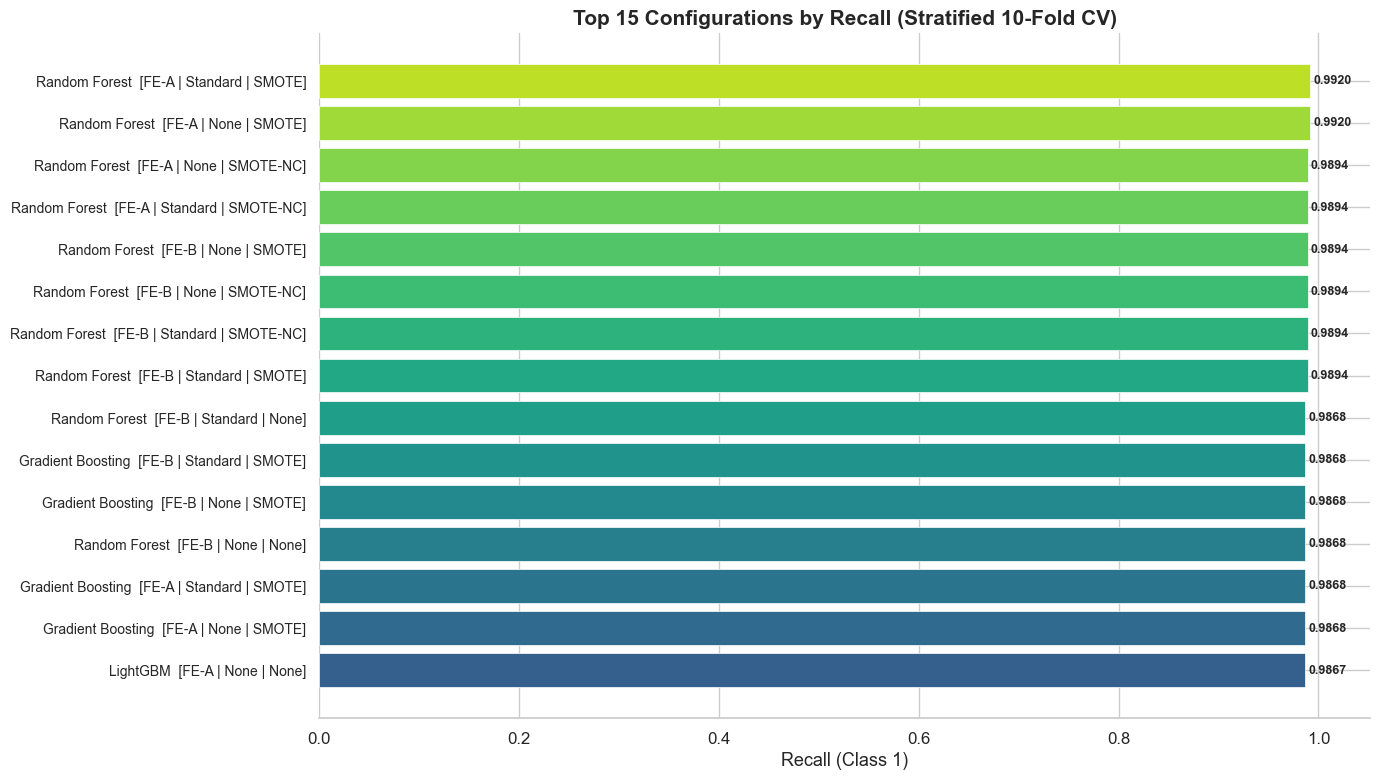

In [58]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import os
os.makedirs("../reports/figures", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)

# --- Top 15 Configurations by Recall_1 ---
fig, ax = plt.subplots(figsize=(14, 8))
top = leaderboard.head(15).iloc[::-1]
labels = top.apply(
    lambda r: f"{r['Model']}  [{r['FE']} | {r['Scaling']} | {r['Resampler']}]", axis=1
)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top)))
ax.barh(range(len(top)), top["Recall_1"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Recall (Class 1)", fontsize=13)
ax.set_title("Top 15 Configurations by Recall (Stratified 10-Fold CV)",
             fontsize=15, fontweight="bold")
for i, v in enumerate(top["Recall_1"]):
    ax.text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=9, fontweight="bold")
ax.set_xlim(right=top["Recall_1"].max() + 0.06)
sns.despine(left=True)
plt.tight_layout()
plt.savefig("../reports/figures/top15_recall.png", dpi=150, bbox_inches="tight")
plt.show()

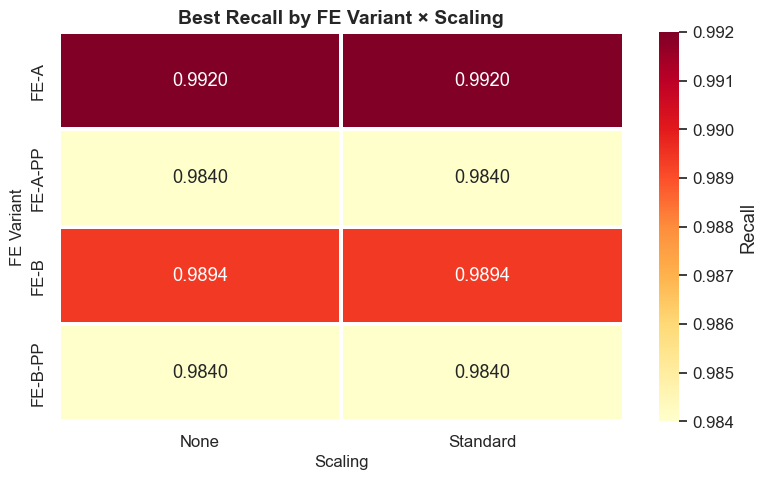

In [59]:
# --- Recall Heatmap: FE Variant x Scaling (best per combo) ---
pivot = leaderboard.groupby(["FE", "Scaling"])["Recall_1"].max().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax,
            linewidths=1.5, linecolor="white", cbar_kws={"label": "Recall"})
ax.set_title("Best Recall by FE Variant \u00d7 Scaling",
             fontsize=14, fontweight="bold")
ax.set_ylabel("FE Variant", fontsize=12)
ax.set_xlabel("Scaling", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/recall_heatmap_fe_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

## CV Strategy Comparison: KFold-10 vs StratifiedKFold-10

In [60]:
cv_records = []
for fe_name, (X_tr, _) in FE_VARIANTS.items():
    cat_idx = get_cat_indices(X_tr)
    for scale_name, scale in SCALING_OPTIONS:
        for mdl_name, mdl in BASE_MODELS.items():
            for cv_name, cv in [("KFold-10", KF), ("StratifiedKFold-10", SKF)]:
                try:
                    pipe   = build_pipeline("None", mdl, cat_idx, scale=scale)
                    cv_res = cross_validate(pipe, X_tr, y_train, cv=cv,
                                            scoring=SCORING, n_jobs=-1)
                    cv_records.append({
                        "FE"         : fe_name,
                        "Scaling"    : scale_name,
                        "Model"      : mdl_name,
                        "CV Strategy": cv_name,
                        "Accuracy"   : round(cv_res["test_accuracy"].mean(),    4),
                        "Precision_1": round(cv_res["test_precision_1"].mean(), 4),
                        "Recall_1"   : round(cv_res["test_recall_1"].mean(),    4),
                        "F1_1"       : round(cv_res["test_f1_1"].mean(),        4),
                    })
                except Exception as exc:
                    print(f"  SKIPPED {fe_name} | {scale_name} | {mdl_name} | {cv_name}: {exc}")

cv_comp_df = pd.DataFrame(cv_records).sort_values(["FE", "Scaling", "Model", "CV Strategy"])
display(cv_comp_df.reset_index(drop=True))

,FE,Scaling,Model,CV Strategy,Accuracy,Precision_1,Recall_1,F1_1
0,FE-A,None,Decision Tree,KFold-10,0.9625,0.9517,0.9557,0.9532
1,FE-A,None,Decision Tree,StratifiedKFold-10,0.9603,0.9539,0.9496,0.9508
2,FE-A,None,Extra Trees,KFold-10,0.9786,0.9692,0.9758,0.9723
3,FE-A,None,Extra Trees,StratifiedKFold-10,0.9796,0.9766,0.9735,0.9748
4,FE-A,None,Gradient Boosting,KFold-10,0.9893,0.9851,0.9876,0.9861
...,...,...,...,...,...,...,...,...
123,FE-B-PP,Standard,Random Forest,StratifiedKFold-10,0.9796,0.9694,0.9813,0.9750
124,FE-B-PP,Standard,SVM,KFold-10,0.9679,0.9563,0.9643,0.9600
125,FE-B-PP,Standard,SVM,StratifiedKFold-10,0.9678,0.9494,0.9733,0.9608
126,FE-B-PP,Standard,XGBoost,KFold-10,0.9775,0.9721,0.9717,0.9716


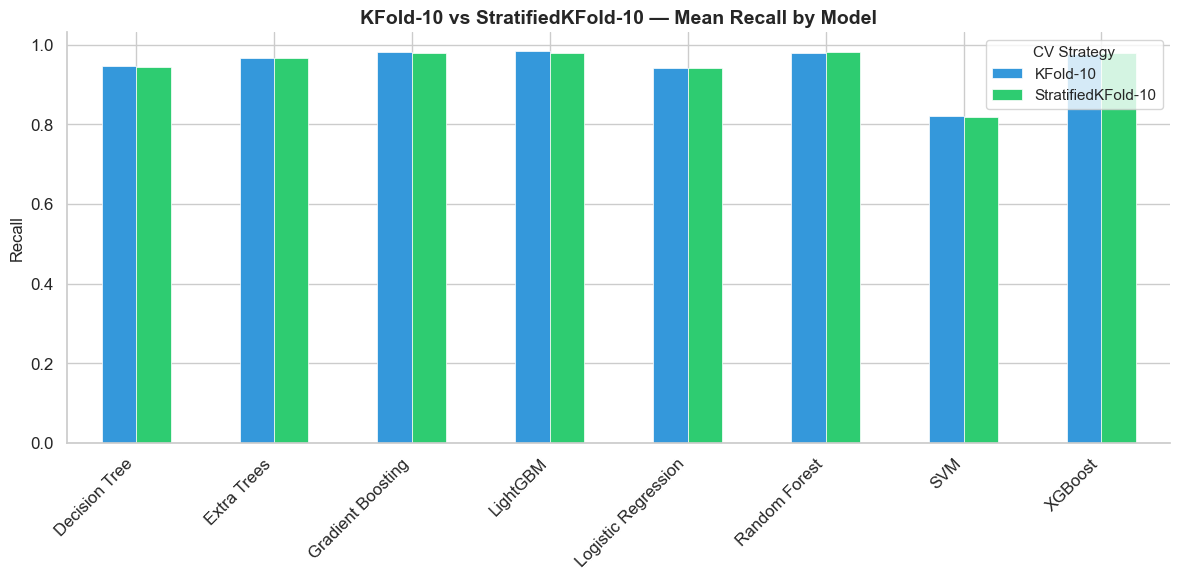

In [ ]:
# cv stra
cv_pivot = cv_comp_df.groupby(["Model", "CV Strategy"])["Recall_1"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
cv_pivot.plot(kind="bar", ax=ax, color=["#3498db", "#2ecc71"],
              edgecolor="white", linewidth=0.5)
ax.set_title("KFold-10 vs StratifiedKFold-10 — Mean Recall by Model",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Recall", fontsize=12)
ax.set_xlabel("")
ax.legend(title="CV Strategy", fontsize=11, title_fontsize=11)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("../reports/figures/cv_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Ensemble Learning: VotingClassifier + BaggingClassifier

In [62]:
top3_names = (
    leaderboard.groupby("Model")["Recall_1"]
    .max().sort_values(ascending=False).head(3).index.tolist()
)
best_row        = leaderboard.iloc[0]
best_fe         = best_row["FE"]
best_res        = best_row["Resampler"]
best_scale      = best_row["Scaling"]
best_scale_bool = (best_scale == "Standard")
X_tr_ens, X_te_ens = FE_VARIANTS[best_fe]
cat_idx_ens = get_cat_indices(X_tr_ens)

print(f"top-3 models: {top3_names}")
print(f"best FE: {best_fe}  |  best scaling: {best_scale}  |  best resampler: {best_res}")

estimators_ens = [
    (name.lower().replace(" ", "_"), build_pipeline(best_res, BASE_MODELS[name], cat_idx_ens, scale=best_scale_bool))
    for name in top3_names
]

ensemble_records = []

for vote_type in ["hard", "soft"]:
    vc = VotingClassifier(estimators=copy.deepcopy(estimators_ens), voting=vote_type)
    vc.fit(X_tr_ens, y_train)
    y_pred = vc.predict(X_te_ens)
    rep = classification_report(y_test, y_pred, output_dict=True)
    ensemble_records.append({
        "Model"      : f"VotingClassifier ({vote_type})",
        "Recall_1"   : round(rep["1"]["recall"],    4),
        "Precision_1": round(rep["1"]["precision"], 4),
        "F1_1"       : round(rep["1"]["f1-score"],  4),
        "Accuracy"   : round(accuracy_score(y_test, y_pred), 4),
    })

# bagging with #1 base estimator pipeline
bag = BaggingClassifier(estimator=copy.deepcopy(estimators_ens[0][1]),
                         n_estimators=50, random_state=RS, n_jobs=-1)
bag.fit(X_tr_ens, y_train)
y_pred_bag = bag.predict(X_te_ens)
rep_bag = classification_report(y_test, y_pred_bag, output_dict=True)
ensemble_records.append({
    "Model"      : f"BaggingClassifier (base={top3_names[0]})",
    "Recall_1"   : round(rep_bag["1"]["recall"],    4),
    "Precision_1": round(rep_bag["1"]["precision"], 4),
    "F1_1"       : round(rep_bag["1"]["f1-score"],  4),
    "Accuracy"   : round(accuracy_score(y_test, y_pred_bag), 4),
})

ensemble_df = pd.DataFrame(ensemble_records).sort_values("Recall_1", ascending=False)
display(ensemble_df)

top-3 models: ['Random Forest', 'Gradient Boosting', 'XGBoost']
best FE: FE-A  |  best scaling: Standard  |  best resampler: SMOTE


,Model,Recall_1,Precision_1,F1_1,Accuracy
0,VotingClassifier (hard),0.9895,0.9895,0.9895,0.9915
1,VotingClassifier (soft),0.9895,0.9895,0.9895,0.9915
2,BaggingClassifier (base=Random Forest),0.9895,0.9895,0.9895,0.9915


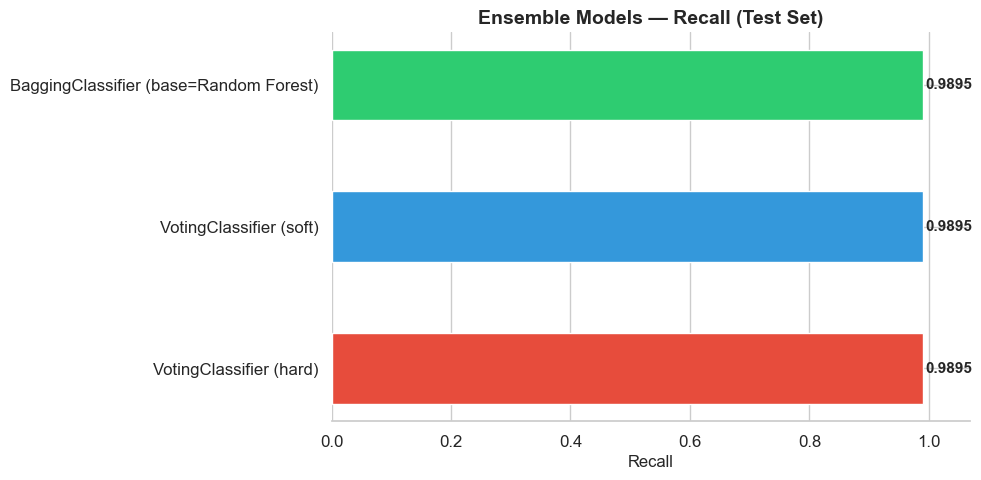

In [ ]:
# compare ensemble model
fig, ax = plt.subplots(figsize=(10, 5))
ens_sorted = ensemble_df.sort_values("Recall_1", ascending=True)
palette = ["#e74c3c", "#3498db", "#2ecc71"][:len(ens_sorted)]
ax.barh(ens_sorted["Model"], ens_sorted["Recall_1"],
        color=palette, edgecolor="white", height=0.5)
for i, (_, row) in enumerate(ens_sorted.iterrows()):
    ax.text(row["Recall_1"] + 0.004, i,
            f"{row['Recall_1']:.4f}", va="center", fontsize=11, fontweight="bold")
ax.set_title("Ensemble Models — Recall (Test Set)", fontsize=14, fontweight="bold")
ax.set_xlabel("Recall", fontsize=12)
ax.set_xlim(right=ens_sorted["Recall_1"].max() + 0.08)
sns.despine(left=True)
plt.tight_layout()
plt.savefig("../reports/figures/ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Optuna Hyperparameter Tuning (Best Model Only)

In [64]:
best_mdl_name        = leaderboard.iloc[0]["Model"]
best_fe_tune         = leaderboard.iloc[0]["FE"]
best_res_tune        = leaderboard.iloc[0]["Resampler"]
best_scale_tune      = leaderboard.iloc[0]["Scaling"]
best_scale_tune_bool = (best_scale_tune == "Standard")
X_tr_tune, X_te_tune = FE_VARIANTS[best_fe_tune]
cat_idx_tune = get_cat_indices(X_tr_tune)

print(f"optuna target: {best_mdl_name}  |  FE: {best_fe_tune}  |  scaling: {best_scale_tune}  |  resampler: {best_res_tune}")

skf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
scorer_recall = make_scorer(recall_score, pos_label=1, zero_division=0)


def build_tuned_model(trial, model_name):
    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators     =trial.suggest_int("n_estimators",       100, 500),
            max_depth        =trial.suggest_int("max_depth",            3,  10),
            learning_rate    =trial.suggest_float("learning_rate",   0.01, 0.30, log=True),
            subsample        =trial.suggest_float("subsample",        0.60, 1.00),
            colsample_bytree =trial.suggest_float("colsample_bytree", 0.60, 1.00),
            scale_pos_weight =trial.suggest_float("scale_pos_weight", 1.00, 5.00),
            random_state=RS, verbosity=0, eval_metric="logloss", n_jobs=-1,
        )
    if model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators =trial.suggest_int("n_estimators",  100, 500),
            max_depth    =trial.suggest_int("max_depth",       3,  10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.30, log=True),
            class_weight =trial.suggest_categorical("class_weight", ["balanced", None]),
            random_state=RS, verbose=-1, n_jobs=-1,
        )
    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators     =trial.suggest_int("n_estimators",        100, 500),
            max_depth        =trial.suggest_int("max_depth",             3,  20),
            min_samples_split=trial.suggest_int("min_samples_split",     2,  10),
            class_weight     =trial.suggest_categorical("class_weight", ["balanced", None]),
            random_state=RS, n_jobs=-1,
        )
    if model_name == "Extra Trees":
        return ExtraTreesClassifier(
            n_estimators     =trial.suggest_int("n_estimators",        100, 500),
            max_depth        =trial.suggest_int("max_depth",             3,  20),
            min_samples_split=trial.suggest_int("min_samples_split",     2,  10),
            class_weight     =trial.suggest_categorical("class_weight", ["balanced", None]),
            random_state=RS, n_jobs=-1,
        )
    if model_name == "Logistic Regression":
        return LogisticRegression(
            C           =trial.suggest_float("C", 0.01, 10, log=True),
            class_weight=trial.suggest_categorical("class_weight", ["balanced", None]),
            random_state=RS, max_iter=1000,
        )
    if model_name == "SVM":
        return SVC(
            C           =trial.suggest_float("C", 0.01, 10, log=True),
            kernel      =trial.suggest_categorical("kernel", ["rbf", "linear"]),
            class_weight=trial.suggest_categorical("class_weight", ["balanced", None]),
            random_state=RS, probability=True,
        )
    if model_name == "Gradient Boosting":
        return GradientBoostingClassifier(
            n_estimators =trial.suggest_int("n_estimators",  100, 400),
            max_depth    =trial.suggest_int("max_depth",       3,   8),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.30, log=True),
            random_state=RS,
        )
    if model_name == "Decision Tree":
        return DecisionTreeClassifier(
            max_depth        =trial.suggest_int("max_depth",             3,  20),
            min_samples_split=trial.suggest_int("min_samples_split",     2,  10),
            class_weight     =trial.suggest_categorical("class_weight", ["balanced", None]),
            random_state=RS,
        )
    raise ValueError(f"no search space defined for: {model_name!r}")


def objective(trial):
    m    = build_tuned_model(trial, best_mdl_name)
    pipe = build_pipeline(best_res_tune, m, cat_idx_tune, scale=best_scale_tune_bool)
    cv   = cross_validate(pipe, X_tr_tune, y_train,
                           cv=skf_inner, scoring=SCORING, n_jobs=-1)
    return cv["test_recall_1"].mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nbest recall (CV): {study.best_value:.4f}")
print(f"best params: {study.best_params}")

optuna target: Random Forest  |  FE: FE-A  |  scaling: Standard  |  resampler: SMOTE


Best trial: 0. Best value: 0.989404: 100%|██████████| 50/50 [00:25<00:00,  1.94it/s]


best recall (CV): 0.9894
best params: {'n_estimators': 290, 'max_depth': 13, 'min_samples_split': 9, 'class_weight': None}


In [ ]:
# refit tuned model on full training data and evaluate on test set
tuned_mdl  = build_tuned_model(optuna.trial.FixedTrial(study.best_params), best_mdl_name)
tuned_pipe = build_pipeline(best_res_tune, tuned_mdl, cat_idx_tune, scale=best_scale_tune_bool)
tuned_pipe.fit(X_tr_tune, y_train)
y_pred_tuned = tuned_pipe.predict(X_te_tune)

# untuned baseline on same split for fair comparison
untuned_pipe = build_pipeline(best_res_tune, copy.deepcopy(BASE_MODELS[best_mdl_name]), cat_idx_tune, scale=best_scale_tune_bool)
untuned_pipe.fit(X_tr_tune, y_train)
y_pred_untuned = untuned_pipe.predict(X_te_tune)

tuning_comparison = pd.DataFrame({
    "Untuned": {
        "Recall_1"  : recall_score(y_test, y_pred_untuned, pos_label=1),
        "F1_1"      : f1_score(y_test, y_pred_untuned, pos_label=1),
        "AUC-ROC"   : roc_auc_score(y_test, untuned_pipe.predict_proba(X_te_tune)[:, 1]),
        "Accuracy"  : accuracy_score(y_test, y_pred_untuned),
    },
    "Tuned (Optuna)": {
        "Recall_1"  : recall_score(y_test, y_pred_tuned, pos_label=1),
        "F1_1"      : f1_score(y_test, y_pred_tuned, pos_label=1),
        "AUC-ROC"   : roc_auc_score(y_test, tuned_pipe.predict_proba(X_te_tune)[:, 1]),
        "Accuracy"  : accuracy_score(y_test, y_pred_tuned),
    }
}).T.round(4)

print(f"\ntuning comparison — {best_mdl_name}:")
display(tuning_comparison)


tuning comparison — Random Forest:


,Recall_1,F1_1,AUC-ROC,Accuracy
Untuned,0.9895,0.9895,0.9995,0.9915
Tuned (Optuna),0.9895,0.9792,0.9989,0.9829


## Evaluation Visualizations

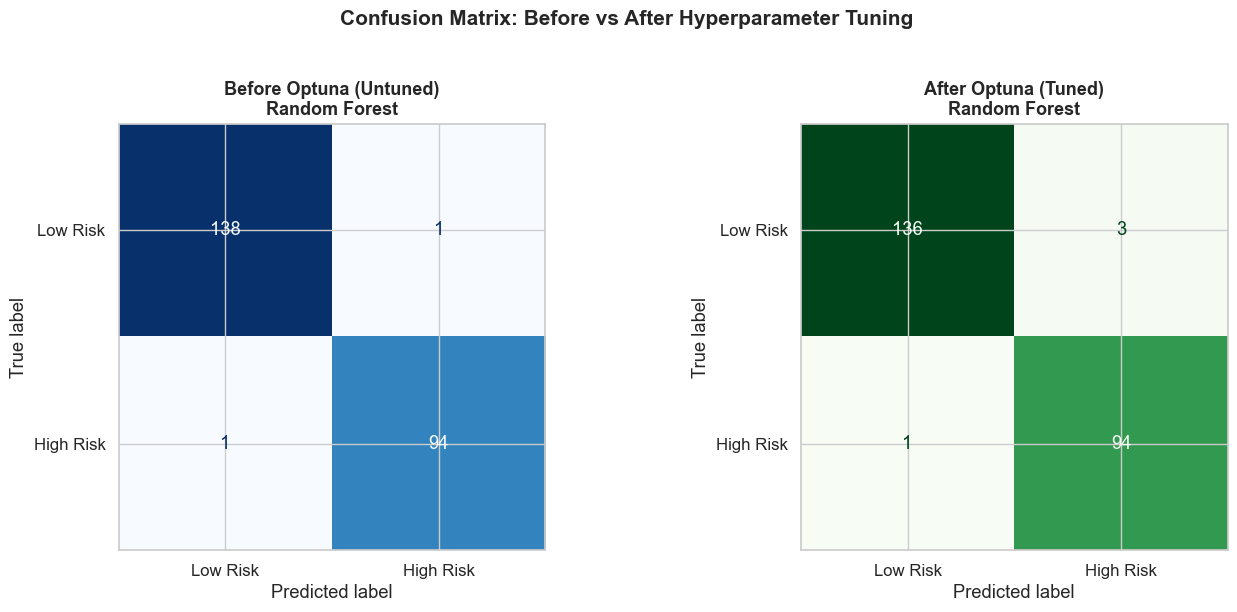

In [ ]:
# before after optuna confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_untuned = confusion_matrix(y_test, y_pred_untuned)
disp1 = ConfusionMatrixDisplay(cm_untuned, display_labels=["Low Risk", "High Risk"])
disp1.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title(f"Before Optuna (Untuned)\n{best_mdl_name}",
                  fontsize=13, fontweight="bold")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp2 = ConfusionMatrixDisplay(cm_tuned, display_labels=["Low Risk", "High Risk"])
disp2.plot(ax=axes[1], cmap="Greens", values_format="d", colorbar=False)
axes[1].set_title(f"After Optuna (Tuned)\n{best_mdl_name}",
                  fontsize=13, fontweight="bold")

fig.suptitle("Confusion Matrix: Before vs After Hyperparameter Tuning",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

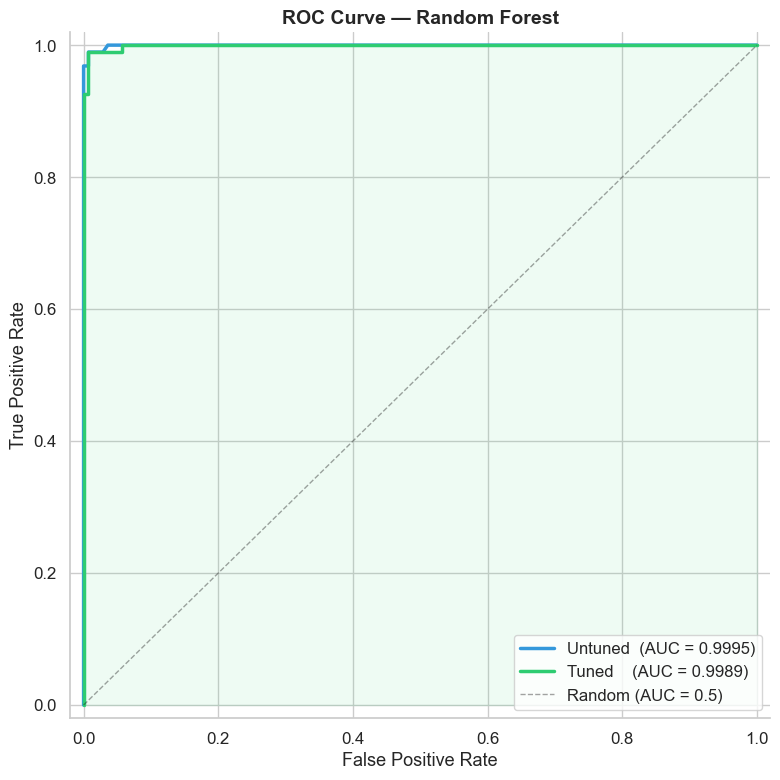

In [ ]:
# roc auc curve
y_prob_tuned   = tuned_pipe.predict_proba(X_te_tune)[:, 1]
y_prob_untuned = untuned_pipe.predict_proba(X_te_tune)[:, 1]

fpr_u, tpr_u, _ = roc_curve(y_test, y_prob_untuned)
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)
auc_u = auc(fpr_u, tpr_u)
auc_t = auc(fpr_t, tpr_t)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr_u, tpr_u, color="#3498db", lw=2.5,
        label=f"Untuned  (AUC = {auc_u:.4f})")
ax.plot(fpr_t, tpr_t, color="#2ecc71", lw=2.5,
        label=f"Tuned    (AUC = {auc_t:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random (AUC = 0.5)")
ax.fill_between(fpr_t, tpr_t, alpha=0.08, color="#2ecc71")

ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title(f"ROC Curve — {best_mdl_name}", fontsize=14, fontweight="bold")
ax.legend(fontsize=12, loc="lower right")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
sns.despine()
plt.tight_layout()
plt.savefig("../reports/figures/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Best Model and Test Data

In [69]:
import os
os.makedirs("../models", exist_ok=True)

# determine overall best pipeline: compare tuned model against leaderboard top
best_recall_tuned   = recall_score(y_test, y_pred_tuned, pos_label=1)
best_recall_untuned = leaderboard.iloc[0]["Recall_1"]

if best_recall_tuned >= best_recall_untuned:
    best_final_pipe    = tuned_pipe
    best_final_X_train = X_tr_tune
    best_final_X_test  = X_te_tune
    print(f"saving tuned model  (recall={best_recall_tuned:.4f})")
else:
    # refit leaderboard #1 configuration on its split
    row0       = leaderboard.iloc[0]
    Xtr0, Xte0 = FE_VARIANTS[row0["FE"]]
    cat0       = get_cat_indices(Xtr0)
    scale0     = (row0["Scaling"] == "Standard")
    pipe0      = build_pipeline(row0["Resampler"], copy.deepcopy(BASE_MODELS[row0["Model"]]), cat0, scale=scale0)
    pipe0.fit(Xtr0, y_train)
    best_final_pipe    = pipe0
    best_final_X_train = Xtr0
    best_final_X_test  = Xte0
    print(f"saving leaderboard #1 (recall={best_recall_untuned:.4f})")

feature_names_final = best_final_X_train.columns.tolist()

payload = {
    "pipeline"     : best_final_pipe,
    "feature_names": feature_names_final,
    "model_name"   : best_mdl_name,
    "X_test"       : best_final_X_test,
    "y_test"       : y_test,
}

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(payload, f)

print("saved → ../models/best_model.pkl")
print(f"features ({len(feature_names_final)}): {feature_names_final}")

saving leaderboard #1 (recall=0.9920)
saved → ../models/best_model.pkl
features (12): ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Is_Fever']


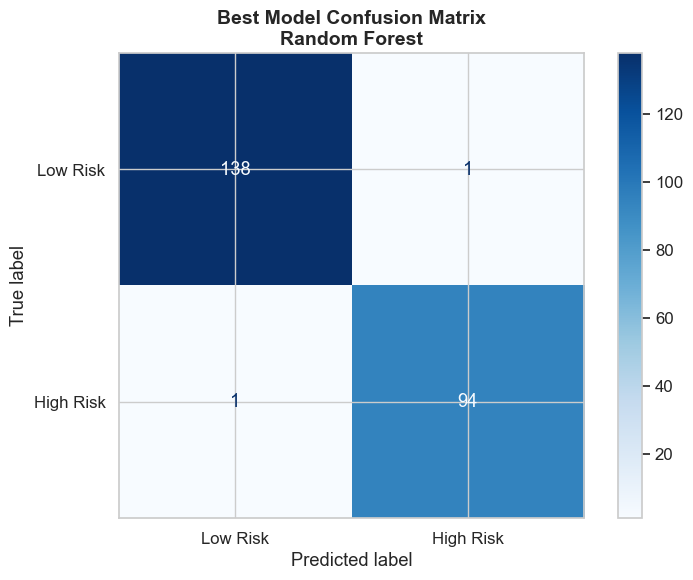


Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99       139
   High Risk       0.99      0.99      0.99        95

    accuracy                           0.99       234
   macro avg       0.99      0.99      0.99       234
weighted avg       0.99      0.99      0.99       234



In [ ]:
# best model confusion matrix & classification report
y_pred_final = best_final_pipe.predict(best_final_X_test)
cm_final = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_final, display_labels=["Low Risk", "High Risk"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Best Model Confusion Matrix\n{best_mdl_name}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/best_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=["Low Risk", "High Risk"]))